In [1]:
#importing libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#Loading data
data=pd.read_csv(r"C:\Users\LENOVO\OneDrive\Desktop\BMW sales data (2010-2024).csv")
data.head()

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low


In [3]:
#checking the no. of rows and columns
data.shape

(50000, 11)

In [4]:
#checking for duplicate values
data.duplicated().sum()

0

In [5]:
#checking fo null values
data.isnull().sum()

Model                   0
Year                    0
Region                  0
Color                   0
Fuel_Type               0
Transmission            0
Engine_Size_L           0
Mileage_KM              0
Price_USD               0
Sales_Volume            0
Sales_Classification    0
dtype: int64

In [6]:
#Data manipulation as per requirement
data['Price_INR']=data['Price_USD']*90.5
data.head()

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification,Price_INR
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High,8935970.0
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low,7169319.5
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low,10250482.5
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low,5517875.5
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low,4515769.0


In [7]:
#Data manipulation as per requirement
mapping_dict = {'Manual': 0, 'Automatic': 1}
data['Transmission'] = data['Transmission'].map(mapping_dict)

In [8]:
#Data manipulation as per requirement
mapping_dict2 = {'Petrol': 0, 'Diesel': 1, 'Electric': 2, 'Hybrid': 3}
data['Fuel_Type'] = data['Fuel_Type'].map(mapping_dict2)

In [9]:
#Changing data types
data["Price_INR"]=data["Price_INR"].astype("int64")
data["Year"]=data["Year"].astype("int64")
data["Price_INR"].dtype

dtype('int64')

In [10]:
#Changing data types
data["Total_INR_Sale"]=data["Sales_Volume"]*data["Price_INR"].astype("int64")
data["Total_USD_Sale"]=data["Sales_Volume"]*data["Price_USD"].astype("int64")

In [11]:
#Getting data info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Model                 50000 non-null  object 
 1   Year                  50000 non-null  int64  
 2   Region                50000 non-null  object 
 3   Color                 50000 non-null  object 
 4   Fuel_Type             50000 non-null  int64  
 5   Transmission          50000 non-null  int64  
 6   Engine_Size_L         50000 non-null  float64
 7   Mileage_KM            50000 non-null  int64  
 8   Price_USD             50000 non-null  int64  
 9   Sales_Volume          50000 non-null  int64  
 10  Sales_Classification  50000 non-null  object 
 11  Price_INR             50000 non-null  int64  
 12  Total_INR_Sale        50000 non-null  int64  
 13  Total_USD_Sale        50000 non-null  int64  
dtypes: float64(1), int64(9), object(4)
memory usage: 5.3+ MB


In [12]:
#Reading data
data.head()

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification,Price_INR,Total_INR_Sale,Total_USD_Sale
0,5 Series,2016,Asia,Red,0,0,3.5,151748,98740,8300,High,8935970,74168551000,819542000
1,i8,2013,North America,Red,3,1,1.6,121671,79219,3428,Low,7169319,24576425532,271562732
2,5 Series,2022,North America,Blue,0,1,4.5,10991,113265,6994,Low,10250482,71691871108,792175410
3,X3,2024,Middle East,Blue,0,1,1.7,27255,60971,4047,Low,5517875,22330840125,246749637
4,7 Series,2020,South America,Black,1,0,2.1,122131,49898,3080,Low,4515769,13908568520,153685840


In [13]:
Highly_sold_model=data["Model"].max()
print("Highly sold model is",Highly_sold_model)

Highly sold model is i8


In [14]:
#Model with highest price as Per Indian Pricing
Highest_Price_INR=data["Price_INR"].max()
Model_name=(data.set_index('Model')['Price_INR'].idxmax())
print("Model with Highest Price in India is",Model_name)

Model with Highest Price in India is i8


In [15]:
#Model with Highest Mileage
High_Mileage=data["Mileage_KM"].max()
Model_name=(data.set_index('Model')['Mileage_KM'].idxmax())
print("High Mileage giving Car is",Model_name)

High Mileage giving Car is X3


In [16]:
#Models with Highest sold quantity in 2024
Model_name=data[data["Year"]==2024].groupby("Model")["Sales_Volume"].max()
print("Highest Sold Volume is",Model_name)

Highest Sold Volume is Model
3 Series    9979
5 Series    9999
7 Series    9999
M3          9993
M5          9975
X1          9980
X3          9975
X5          9946
X6          9980
i3          9981
i8          9937
Name: Sales_Volume, dtype: int64


In [17]:
#Models with Lowest sold quantity in 2024
data_2024 = data[data["Year"] == 2024]
data_min = data_2024.groupby("Model")["Sales_Volume"].min()
print("Lowest Sold Volume is",data_min)

Lowest Sold Volume is Model
3 Series    152
5 Series    101
7 Series    104
M3          228
M5          114
X1          105
X3          151
X5          107
X6          131
i3          126
i8          152
Name: Sales_Volume, dtype: int64


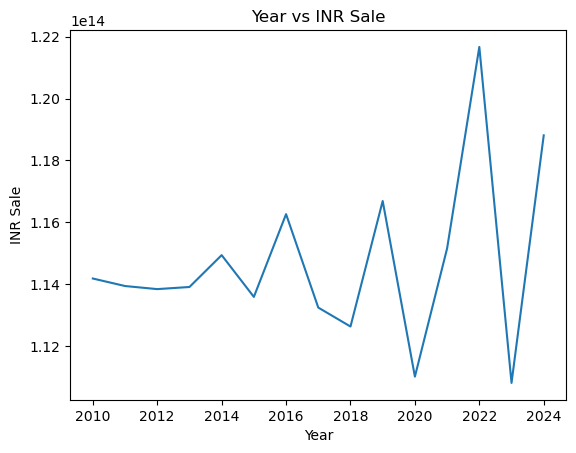

In [18]:
#Year Wise INR Sale 
yearly_sales = data.groupby("Year")["Total_INR_Sale"].sum()
yearly_sales.plot(kind="line")
plt.title("Year vs INR Sale")
plt.xlabel("Year")
plt.ylabel("INR Sale")
plt.show()

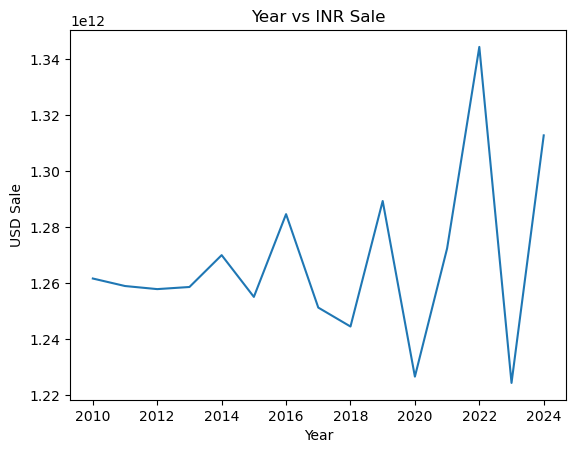

In [19]:
#Year Wise USD Sale
yearly_sales = data.groupby("Year")["Total_USD_Sale"].sum()
yearly_sales.plot(kind="line")
plt.title("Year vs INR Sale")
plt.xlabel("Year")
plt.ylabel("USD Sale")
plt.show()

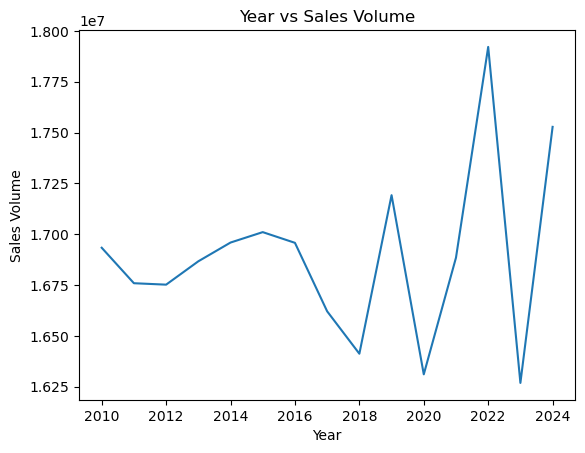

In [20]:
#Quantity sold every year
yearly_sold_qty = data.groupby("Year")["Sales_Volume"].sum()
yearly_sold_qty.plot(kind="line")
plt.title("Year vs Sales Volume")
plt.xlabel("Year")
plt.ylabel("Sales Volume")
plt.show()

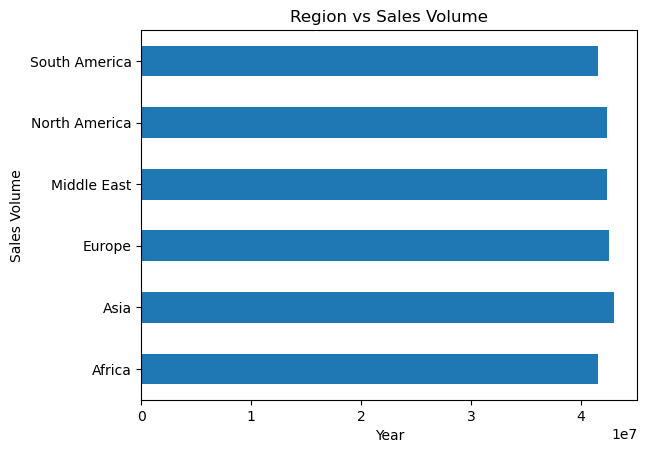

In [21]:
#Quantity sold in a particular region
yearly_sold_qty = data.groupby("Region")["Sales_Volume"].sum()
yearly_sold_qty.plot(kind="barh")
plt.title("Region vs Sales Volume")
plt.xlabel("Year")
plt.ylabel("Sales Volume")
plt.show()

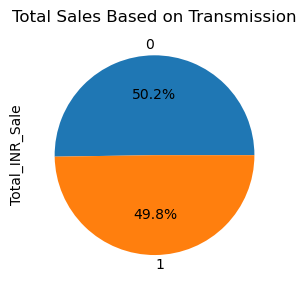

In [33]:
#Sales based on Transmission (Manual=0, Automatic=1)
sale_by_transmission = data.groupby('Transmission')['Total_INR_Sale'].sum()
sale_by_transmission.plot(kind='pie',autopct='%1.1f%%', figsize=(3,3))
plt.title("Total Sales Based on Transmission")
plt.tight_layout()
plt.show()

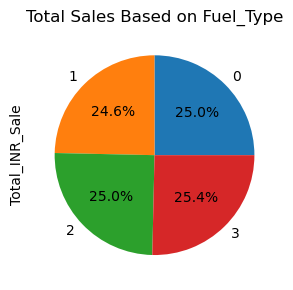

In [34]:
#Sales based on Transmission (Petrol=0,Diesel=1,Electric=2,Hybrid=3)
sale_by_Fuel_Type = data.groupby('Fuel_Type')['Total_INR_Sale'].sum()
sale_by_Fuel_Type.plot(kind='pie',autopct='%1.1f%%', figsize=(3,3))
plt.title("Total Sales Based on Fuel_Type")
plt.tight_layout()
plt.show()